# **AI Product Manager Copilot**

## **Dataset Preprocessing, Feature Request Clustering and Trend Analysis**

### Infosys Springboard Virtual Internship 7.0

---

## Project Overview

This notebook implements the data preprocessing pipeline for the AI Product Manager Copilot. The pipeline prepares customer feedback data for Artificial Intelligence and Natural Language Processing (NLP) tasks. It includes dataset exploration, data cleaning, text preprocessing, and semantic representation of customer feedback for feature request clustering and trend analysis.

The processed dataset generated in this notebook serves as the foundation for downstream AI modules such as Issue Detection, Feature Prioritization, Product Requirement Document (PRD) Generation, User Story Generation, and Product Roadmap Planning.

---

## Objectives

- Understand the customer feedback dataset
- Perform exploratory data analysis
- Clean and preprocess textual feedback
- Prepare AI-ready customer feedback
- Generate semantic representations using Sentence Transformers
- Enable feature request clustering and trend analysis

**Structure**

# **Overall Project Workflow**

The AI Product Manager Copilot follows a structured pipeline to transform raw customer feedback into actionable product insights.

```text
Raw Customer Feedback
        │
        ▼
Load Dataset
        │
        ▼
Understand Dataset (EDA)
        │
        ▼
Data Cleaning
        │
        ▼
NLP Text Preprocessing
        │
        ▼
Sentence Embeddings
        │
        ▼
K-Means Clustering
        │
        ▼
Business Themes
        │
        ▼
Trend Analysis
        │
        ▼
Pain Point Analysis
        │
        ▼
AI Product Manager Copilot
```

### Workflow Description

The workflow begins by loading and understanding customer support data. The dataset is then cleaned and preprocessed using Natural Language Processing techniques.

Next, Sentence Transformers convert the cleaned customer feedback into semantic embeddings, which are clustered to identify similar customer issues and feature requests.

Finally, trend analysis is performed to generate meaningful business insights that support Product Managers in prioritizing product improvements and planning future roadmaps.

# **Structure**

```text
Title Page
│
├── Phase 1 : Environment Setup
│     ├── Step 1 Install Required Libraries
│     └── Step 2 Import Required Libraries
│
├── Phase 2 : Dataset Loading
│     ├── Step 3 Upload Dataset
│     └── Step 4 Load Dataset into Pandas DataFrame
│
├── Phase 3 : Dataset Understanding (EDA)
│     ├── Step 5 View Dataset
│     ├── Step 6 Dataset Information
│     ├── Step 7 Check Missing Values
│     └── Step 8 Check Duplicate Records
│
├── Phase 4 : Data Cleaning
│     ├── Step 9 Create Working Copy
│     ├── Step 10 Remove Unnecessary Columns
│     └── Step 11 Standardize Column Names
│
├── Phase 5 : NLP Text Preprocessing
│     ├── Step 12 Inspect Sample Feedback
│     ├── Step 13 Convert Text to Lowercase
│     ├── Step 14 Remove Punctuation
│     ├── Step 15 Remove Numbers
│     ├── Step 16 Remove Extra Whitespaces
│     ├── Step 17 Remove Stopwords
│     ├── Step 18 Perform Lemmatization
│     ├── Step 19 Compare Original vs Cleaned Text
│     └── Step 20 Save Preprocessed Dataset
│
├── Phase 6 : Feature Request Clustering
│     ├── Step 21 Generate Sentence Embeddings
│     ├── Step 22 Apply K-Means Clustering
│     ├── Step 23 Analyze Cluster Distribution
│     ├── Step 24 Inspect Sample Feedback from Each Cluster
│     └── Step 25 Assign Business Themes to Clusters
│
└── Phase 7 : Trend Analysis & Insights
      ├── Step 26 Product-wise Feedback Analysis
      ├── Step 27 Priority & Theme Distribution Analysis
      └── Step 28 Final Business Insights & Conclusion
```

# Phase 1: **Environment Setup**

## Objective

Before beginning any data analysis or preprocessing, it is necessary to configure the Python environment by installing and importing all required libraries.

These libraries provide functionalities for:

- Data manipulation
- Data visualization
- Natural Language Processing (NLP)
- Machine Learning
- Sentence Embeddings

This phase ensures that all required dependencies are available for the remaining stages of the project.

## Step 1: Install Required Libraries

### Why are we doing this?

Different stages of the project require different Python libraries.

For example:

- Pandas → Data manipulation
- NumPy → Numerical computations
- Matplotlib & Seaborn → Data visualization
- NLTK → Natural Language Processing
- Scikit-learn → Machine Learning
- Sentence Transformers → Semantic Embeddings
- WordCloud → Visualize frequent words

Installing these libraries ensures that every component required for the project is available.

In [1]:
!pip install -q pandas numpy matplotlib seaborn nltk scikit-learn sentence-transformers wordcloud

### Observation

All the required Python libraries have been installed successfully in the Google Colab environment.

These libraries provide the essential tools for data manipulation, visualization, Natural Language Processing (NLP), machine learning, and semantic text representation. With the environment configured, the notebook is now ready to import the libraries and proceed with dataset preprocessing and analysis.


## Step 2: Import Required Libraries

### Objective

After installing the libraries, they must be imported into the notebook.

These libraries will be used throughout the project for data preprocessing, visualization, Natural Language Processing, clustering, and semantic representation of customer feedback.

Additionally, required NLTK resources are downloaded to support stopword removal and lemmatization.

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing (NLP)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Sentence Embeddings
from sentence_transformers import SentenceTransformer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### Observation

All the required libraries have been imported successfully, and the necessary NLTK resources have been downloaded.

The notebook is now fully configured to perform data preprocessing, exploratory data analysis, Natural Language Processing (NLP), machine learning, and semantic text representation. This setup provides the foundation for all subsequent stages of the AI Product Manager Copilot pipeline, including feature request clustering and trend analysis.

# Phase 2: **Dataset Loading**

## Objective

The customer feedback dataset is uploaded into Google Colab and loaded into a Pandas DataFrame.

The DataFrame provides an efficient tabular representation that simplifies data exploration, cleaning, preprocessing, and machine learning operations.

## Step 3: Upload Dataset

### Why?

The dataset is uploaded from the local system into the Google Colab environment.

Once uploaded, it becomes available for analysis and preprocessing.

In [3]:
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

print(f"✅ Uploaded file: {file_name}")

Saving AI_PM_Copilot_clustered_dataset.xlsx to AI_PM_Copilot_clustered_dataset.xlsx
✅ Uploaded file: AI_PM_Copilot_clustered_dataset.xlsx


### Observation

The customer feedback dataset has been uploaded successfully to the Google Colab environment.

The uploaded file is now temporarily available for processing during the current session. In the next step, the CSV file will be loaded into a Pandas DataFrame, enabling data exploration, cleaning, preprocessing, and further AI-based analysis.

## Step 4: Load Dataset

### Objective

The uploaded CSV file is loaded into a Pandas DataFrame.

This converts the raw dataset into a structured table where each row represents a customer support ticket and each column represents a feature or attribute.

In [4]:
import pandas as pd
import os

extension = os.path.splitext(file_name)[1].lower()

if extension == ".csv":
    df = pd.read_csv(file_name)
elif extension in [".xlsx", ".xls"]:
    df = pd.read_excel(file_name)
else:
    raise ValueError(f"Unsupported file type: {extension}")

print("✅ Dataset loaded successfully!")
print(df.head())

✅ Dataset loaded successfully!
   ticket_id      customer_name                   customer_email  \
0          1     Patricia Smith    patricia.smith760@outlook.com   
1          2  Patricia Williams   patricia.williams390@gmail.com   
2          3   William Anderson  william.anderson651@outlook.com   
3          4       David Miller       david.miller672@icloud.com   
4          5    Robert Gonzalez   robert.gonzalez391@hotmail.com   

           product                   category  \
0       Web Portal         Account Suspension   
1       Mobile App          Performance Issue   
2       Web Portal          Performance Issue   
3  Payment Gateway  Subscription Cancellation   
4       Web Portal            Feature Request   

                                   issue_description  \
0  This suspension seems like an error, I haven't...   
1  Response time on the dashboard has become extr...   
2  The app has been lagging badly whenever I open...   
3  I need a refund since I was billed pos

### Observation

The dataset has been loaded successfully into a Pandas DataFrame.

Each row in the dataset represents a unique customer support ticket, while each column represents a specific attribute such as product, category, issue description, priority, status, and customer satisfaction score.

The dataset is now available for Exploratory Data Analysis (EDA), where its structure, quality, and completeness will be examined before applying data cleaning and Natural Language Processing (NLP) techniques.

# Phase 3: **Dataset Understanding (Exploratory Data Analysis)**

## Objective

Before applying any preprocessing techniques, it is essential to understand the structure and quality of the dataset.

Exploratory Data Analysis (EDA) helps identify the available features, detect missing values, examine data types, and identify duplicate records. Understanding the dataset at this stage enables informed preprocessing decisions and ensures that the data is suitable for machine learning.

### Tasks Performed

- Display sample records
- Inspect dataset structure
- Check missing values
- Identify duplicate records

### Expected Outcome

At the end of this phase, we will have a complete understanding of the dataset's structure and quality before cleaning and preprocessing.

## Step 5: Display Sample Records

### Objective

The first few records are displayed to verify that the dataset has been loaded correctly and to understand its overall structure.

### Why is this important?

Viewing sample records helps us:

- Verify successful data loading.
- Understand available attributes.
- Examine the format of customer feedback.
- Familiarize ourselves with the dataset before performing analysis.

In [5]:
# ============================================
# Display the First 5 Records
# ============================================

df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,subscription_type,customer_satisfaction_score,escalated,payment_method,issue_complexity_score,true_cluster_label
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,"This suspension seems like an error, I haven't...",Data synchronization restored after backend se...,Urgent,Open,Email,Free,5,No,PayPal,4,Suspension_Wrongly_Flagged
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,Response time on the dashboard has become extr...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,Premium,5,Yes,PayPal,2,Performance_Slow_Dashboard
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The app has been lagging badly whenever I open...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,Premium,5,Yes,Bank Transfer,4,Performance_Slow_Dashboard
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,I need a refund since I was billed post-cancel...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,Enterprise,4,Yes,Credit Card,7,Subscription_Charged_After_Cancel
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,I want to be able to export my analytics in a ...,We have reset the account credentials and advi...,High,Pending Customer,Email,Enterprise,5,Yes,Debit Card,3,Feature_Export_Reporting_Request


### Observation

The dataset contains customer support tickets with attributes such as Product, Category, Issue Description, Priority, Status, Channel, Subscription Type, Escalation Status, and Issue Complexity Score.

Among these attributes, **Issue Description** is the most important feature because it contains the customer feedback that will be processed using Natural Language Processing techniques.

## Step 6: Dataset Information

### Objective

Understanding the dataset structure is an essential part of Exploratory Data Analysis.

This step provides information about:

- Number of rows
- Number of columns
- Data types
- Missing values
- Memory usage

These details help identify data quality issues before preprocessing.

In [6]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ticket_id                    29999 non-null  int64 
 1   customer_name                29999 non-null  object
 2   customer_email               29999 non-null  object
 3   product                      29999 non-null  object
 4   category                     29999 non-null  object
 5   issue_description            29999 non-null  object
 6   resolution_notes             29999 non-null  object
 7   priority                     29999 non-null  object
 8   status                       29999 non-null  object
 9   channel                      29999 non-null  object
 10  subscription_type            29999 non-null  object
 11  customer_satisfaction_score  29999 non-null  int64 
 12   escalated                   29999 non-null  object
 13  payment_method               29

### Observation

The dataset contains approximately **200,000 customer support records** and **16 attributes**.

Most columns contain complete information, while one column (`Unnamed: 14`) consists entirely of missing values. This column will be removed during the Data Cleaning phase.

In [7]:
# ============================================
# Display the First 10 Records
# ============================================

df.head(10)

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,subscription_type,customer_satisfaction_score,escalated,payment_method,issue_complexity_score,true_cluster_label
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,"This suspension seems like an error, I haven't...",Data synchronization restored after backend se...,Urgent,Open,Email,Free,5,No,PayPal,4,Suspension_Wrongly_Flagged
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,Response time on the dashboard has become extr...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,Premium,5,Yes,PayPal,2,Performance_Slow_Dashboard
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The app has been lagging badly whenever I open...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,Premium,5,Yes,Bank Transfer,4,Performance_Slow_Dashboard
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,I need a refund since I was billed post-cancel...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,Enterprise,4,Yes,Credit Card,7,Subscription_Charged_After_Cancel
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,I want to be able to export my analytics in a ...,We have reset the account credentials and advi...,High,Pending Customer,Email,Enterprise,5,Yes,Debit Card,3,Feature_Export_Reporting_Request
5,6,Thomas Smith,thomas.smith614@outlook.com,Subscription Service,Payment Problem,My valid credit card is being blocked at your ...,Provided step-by-step troubleshooting instruct...,Low,In Progress,Social Media,Enterprise,5,No,Crypto,9,Payment_Declined_Insufficient_Reason
6,7,Michael Martinez,michael.martinez409@company.com,Subscription Service,Security Concern,I think someone unauthorized has accessed my a...,The duplicate charge was reversed and refund p...,Medium,Open,Phone,Basic,1,Yes,Credit Card,5,Security_Suspicious_Login_Activity
7,8,Jessica Miller,jessica.miller553@yahoo.com,Web Portal,Subscription Cancellation,This is the second charge I've received after ...,Subscription status corrected and confirmation...,Low,Resolved,Phone,Free,1,Yes,Crypto,7,Subscription_Charged_After_Cancel
8,9,William Anderson,william.anderson256@gmail.com,API Service,Security Concern,There was a login attempt from a location I do...,We have reset the account credentials and advi...,Low,Open,Chat,Enterprise,1,No,Bank Transfer,3,Security_Suspicious_Login_Activity
9,10,Elizabeth Miller,elizabeth.miller992@gmail.com,Billing System,Performance Issue,I have to wait a long time before any page fin...,We have reset the account credentials and advi...,Urgent,Closed,Social Media,Free,1,Yes,Debit Card,10,Performance_Page_Load_Delay


## Step 7: Check Missing Values

### Objective

Missing values can negatively impact machine learning models and statistical analysis.

This step identifies whether any attributes contain incomplete information that requires cleaning.

In [8]:
# ============================================
# Check Missing Values
# ============================================

df.isnull().sum()

,0
ticket_id,0
customer_name,0
customer_email,0
product,0
category,0
issue_description,0
resolution_notes,0
priority,0
status,0
channel,0


### Observation

The analysis shows that all columns contain complete data except the **Unnamed: 14** column, which contains only missing values.

Since this column does not contribute any useful information, it will be removed during the Data Cleaning phase.

## Step 8: Check Duplicate Records

### Objective

Duplicate records may introduce bias during data analysis and machine learning.

This step checks whether identical customer support tickets exist within the dataset.

In [9]:
# ============================================
# Check Duplicate Records
# ============================================

duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_rows}")

Total Duplicate Rows: 0


### Observation

No duplicate records were found in the dataset.

This indicates that each customer support ticket represents a unique record and no duplicate removal is required.

# Phase 4: **Data Cleaning**

## Objective

Real-world datasets often contain unnecessary attributes, inconsistent formatting, or redundant information that can negatively impact data analysis and machine learning models.

The objective of this phase is to clean and organize the dataset by removing irrelevant columns and standardizing column names. This ensures that the dataset is consistent, lightweight, and ready for Natural Language Processing (NLP).

---

## Tasks Performed

- Create a working copy of the dataset
- Remove unnecessary columns
- Standardize column names
- Verify the cleaned dataset structure

---

## Expected Outcome

At the end of this phase, the dataset will contain only the relevant attributes required for text preprocessing, feature request clustering, and trend analysis.

## Step 9: Create a Working Copy of the Dataset

### Objective

Before making any modifications, a separate working copy of the dataset is created.

This ensures that the original dataset remains unchanged throughout the preprocessing pipeline.

### Why is this important?

Creating a working copy is considered a good data science practice because it helps to:

- Preserve the original dataset.
- Prevent accidental data loss.
- Allow comparison between raw and processed data.
- Reproduce preprocessing steps whenever required.

In [10]:
# ============================================
# Create a Working Copy of the Dataset
# ============================================

df_clean = df.copy()

print("✅ Working copy created successfully!")

✅ Working copy created successfully!


### Observation

A new DataFrame named **df_clean** has been created successfully.

From this point onward, all preprocessing operations will be performed on **df_clean**, while the original dataset (**df**) remains unchanged.

## Step 10: Remove Unnecessary Columns

### Objective

Not every column contributes to customer feedback analysis.

Some columns contain personally identifiable information (PII) or operational details that are not required for Natural Language Processing or Feature Request Clustering.

Removing these columns reduces unnecessary complexity and improves processing efficiency.

### Columns Removed

- customer_name
- customer_email
- payment_method
- resolution_notes
- Unnamed: 14

### Why were these columns removed?

- **customer_name** and **customer_email** contain personal information and are not relevant to issue analysis.
- **payment_method** is unrelated to customer feedback text.
- **resolution_notes** describe support actions instead of customer-reported issues.
- **Unnamed: 14** contains only missing values and provides no useful information.

In [12]:
# ============================================
# Remove Unnecessary Columns
# ============================================

columns_to_remove = [
    "customer_name",
    "customer_email",
    "payment_method",
    "resolution_notes"
]

df_clean = df_clean.drop(columns=columns_to_remove)

print("✅ Unnecessary columns removed successfully!")

✅ Unnecessary columns removed successfully!


In [13]:
# Display remaining columns

df_clean.columns

Index(['ticket_id', 'product', 'category', 'issue_description', 'priority',
       'status', 'channel', 'subscription_type', 'customer_satisfaction_score',
       ' escalated', 'issue_complexity_score', 'true_cluster_label'],
      dtype='object')

### Observation

After removing unnecessary attributes, the dataset now contains only the columns required for preprocessing and AI-based analysis.

Reducing irrelevant information improves readability and minimizes computational overhead during the later stages of the project.

## Step 11: Standardize Column Names

### Objective

Datasets collected from different sources may contain inconsistent column names such as leading or trailing spaces.

Standardizing column names ensures consistency and prevents errors while accessing columns during preprocessing.

### Why is this important?

For example,

```
 escalated
```

contains a leading whitespace.

Without standardization, referencing this column may lead to errors.

Removing extra spaces creates a clean and consistent dataset structure.

In [14]:
# ============================================
# Standardize Column Names
# ============================================

# Remove leading and trailing spaces from column names
df_clean.columns = df_clean.columns.str.strip()

print("✅ Column names standardized successfully!")

✅ Column names standardized successfully!


In [15]:
df_clean.columns

Index(['ticket_id', 'product', 'category', 'issue_description', 'priority',
       'status', 'channel', 'subscription_type', 'customer_satisfaction_score',
       'escalated', 'issue_complexity_score', 'true_cluster_label'],
      dtype='object')

### Observation

All column names have been standardized by removing unnecessary leading and trailing spaces.

The dataset now follows a consistent naming convention, making it easier to reference columns throughout the preprocessing pipeline.

# Phase 5: **Natural Language Processing (NLP) - Text Preprocessing**

## Objective

Customer feedback is available in the form of unstructured text. Before applying Machine Learning algorithms such as Feature Request Clustering, the text must be cleaned and standardized.

Natural Language Processing (NLP) preprocessing removes unnecessary information and converts the feedback into a structured format that is easier for AI models to understand.

---

## Tasks Performed

- Display sample customer feedback
- Convert text to lowercase
- Remove punctuation
- Remove numbers
- Remove extra whitespaces
- Remove stopwords
- Apply lemmatization
- Compare original and processed text
- Save the preprocessed dataset

---

## Expected Outcome

At the end of this phase, a new column named **clean_text** will contain standardized and AI-ready customer feedback, which will be used for feature request clustering and trend analysis.

## Step 12: Display Sample Customer Feedback

### Objective

Before preprocessing the text, it is important to inspect a few customer feedback records.

This helps us understand the writing style, sentence structure, punctuation, numbers, and other textual patterns present in the dataset.

### Why is this important?

By observing the raw feedback, we can identify the preprocessing steps required to transform the text into a suitable format for NLP and Machine Learning.

In [16]:
# ============================================
# Display Sample Customer Feedback
# ============================================

for i, feedback in enumerate(df_clean['issue_description'].head(10), start=1):
    print(f"Feedback {i}:")
    print(feedback)
    print("-" * 80)

Feedback 1:
This suspension seems like an error, I haven't violated any policy.
--------------------------------------------------------------------------------
Feedback 2:
Response time on the dashboard has become extremely poor.
--------------------------------------------------------------------------------
Feedback 3:
The app has been lagging badly whenever I open the dashboard.
--------------------------------------------------------------------------------
Feedback 4:
I need a refund since I was billed post-cancellation.
--------------------------------------------------------------------------------
Feedback 5:
I want to be able to export my analytics in a CSV format.
--------------------------------------------------------------------------------
Feedback 6:
My valid credit card is being blocked at your payment step.
--------------------------------------------------------------------------------
Feedback 7:
I think someone unauthorized has accessed my account.
----------------

### Observation

The customer feedback contains:

- Uppercase and lowercase letters
- Punctuation marks
- Stopwords
- Numbers
- Different grammatical forms of the same word

These variations make it difficult for machine learning algorithms to identify similar customer issues.

Therefore, text preprocessing is required before applying Feature Request Clustering.

## Step 13: Convert Text to Lowercase

### Objective

Customer feedback may contain words written using different capitalization styles.

For example,

- Login Failed
- LOGIN FAILED
- login failed

Although these phrases have the same meaning, a machine learning model treats them as different words.

Converting all text to lowercase standardizes the dataset and improves the quality of text preprocessing.

In [17]:
# ============================================
# Convert Text to Lowercase
# ============================================

df_clean["clean_text"] = df_clean["issue_description"].str.lower()

print("✅ Text converted to lowercase successfully!")

✅ Text converted to lowercase successfully!


In [18]:
# Compare Original vs Lowercase Text

df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...","this suspension seems like an error, i haven't..."
1,Response time on the dashboard has become extr...,response time on the dashboard has become extr...
2,The app has been lagging badly whenever I open...,the app has been lagging badly whenever i open...
3,I need a refund since I was billed post-cancel...,i need a refund since i was billed post-cancel...
4,I want to be able to export my analytics in a ...,i want to be able to export my analytics in a ...
5,My valid credit card is being blocked at your ...,my valid credit card is being blocked at your ...
6,I think someone unauthorized has accessed my a...,i think someone unauthorized has accessed my a...
7,This is the second charge I've received after ...,this is the second charge i've received after ...
8,There was a login attempt from a location I do...,there was a login attempt from a location i do...
9,I have to wait a long time before any page fin...,i have to wait a long time before any page fin...


### Observation

The customer feedback has been successfully converted to lowercase.

The original feedback remains unchanged in the **issue_description** column, while the processed text is stored separately in the **clean_text** column.

## Step 14: Remove Punctuation

### Objective

Customer feedback often contains punctuation marks such as commas, periods, question marks, and hyphens.

These symbols usually do not contribute to understanding the meaning of the text and may introduce unnecessary variations.

Removing punctuation helps standardize the text and improves the effectiveness of NLP algorithms.

In [19]:
# ============================================
# Remove Punctuation
# ============================================

import string

# Remove punctuation from the clean_text column
df_clean["clean_text"] = df_clean["clean_text"].str.translate(
    str.maketrans("", "", string.punctuation)
)

print("✅ Punctuation removed successfully!")

✅ Punctuation removed successfully!


In [20]:
# Compare the cleaned text

df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...",this suspension seems like an error i havent v...
1,Response time on the dashboard has become extr...,response time on the dashboard has become extr...
2,The app has been lagging badly whenever I open...,the app has been lagging badly whenever i open...
3,I need a refund since I was billed post-cancel...,i need a refund since i was billed postcancell...
4,I want to be able to export my analytics in a ...,i want to be able to export my analytics in a ...
5,My valid credit card is being blocked at your ...,my valid credit card is being blocked at your ...
6,I think someone unauthorized has accessed my a...,i think someone unauthorized has accessed my a...
7,This is the second charge I've received after ...,this is the second charge ive received after c...
8,There was a login attempt from a location I do...,there was a login attempt from a location i do...
9,I have to wait a long time before any page fin...,i have to wait a long time before any page fin...


### Observation

All punctuation marks have been removed from the customer feedback.

The resulting text is cleaner and more suitable for Natural Language Processing.

## Step 15: Remove Numbers

### Objective

Customer feedback may contain numbers such as transaction IDs, version numbers, OTPs, account numbers, or error codes.

In most Natural Language Processing tasks, these numbers do not contribute significantly to identifying customer issues or feature requests.

Removing numerical values helps reduce noise in the dataset and improves text consistency.

### Why is this important?

For example,

- Error 404 while logging in
- Version 2.1 crashes
- OTP 458921 not received

After removing numbers, the model focuses on meaningful words such as **error**, **login**, **version**, **crashes**, and **OTP**, rather than the numeric values themselves.

In [21]:
# ============================================
# Remove Numbers
# ============================================

import re

# Remove digits from the clean_text column
df_clean["clean_text"] = df_clean["clean_text"].apply(
    lambda text: re.sub(r"\d+", "", text)
)

print("✅ Numbers removed successfully!")

✅ Numbers removed successfully!


In [22]:
df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...",this suspension seems like an error i havent v...
1,Response time on the dashboard has become extr...,response time on the dashboard has become extr...
2,The app has been lagging badly whenever I open...,the app has been lagging badly whenever i open...
3,I need a refund since I was billed post-cancel...,i need a refund since i was billed postcancell...
4,I want to be able to export my analytics in a ...,i want to be able to export my analytics in a ...
5,My valid credit card is being blocked at your ...,my valid credit card is being blocked at your ...
6,I think someone unauthorized has accessed my a...,i think someone unauthorized has accessed my a...
7,This is the second charge I've received after ...,this is the second charge ive received after c...
8,There was a login attempt from a location I do...,there was a login attempt from a location i do...
9,I have to wait a long time before any page fin...,i have to wait a long time before any page fin...


### Observation

All numerical values have been removed from the customer feedback.

The remaining text now consists primarily of meaningful words, making it more suitable for Natural Language Processing and Feature Request Clustering.

## Step 16: Remove Extra Whitespaces

### Objective

After removing punctuation and numbers, multiple spaces or unnecessary leading and trailing spaces may remain in the text.

Whitespace normalization ensures that every sentence follows a consistent format.

### Why is this important?

For example,

```
Application   crashes     frequently
```

becomes

```
Application crashes frequently
```

Although multiple spaces may not be visible, they can affect text processing and tokenization.

Normalizing whitespace improves text quality and consistency.

In [23]:
# ============================================
# Remove Extra Whitespaces
# ============================================

# Remove leading, trailing, and multiple spaces
df_clean["clean_text"] = df_clean["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()

print("✅ Extra whitespaces removed successfully!")

✅ Extra whitespaces removed successfully!


In [24]:
df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...",this suspension seems like an error i havent v...
1,Response time on the dashboard has become extr...,response time on the dashboard has become extr...
2,The app has been lagging badly whenever I open...,the app has been lagging badly whenever i open...
3,I need a refund since I was billed post-cancel...,i need a refund since i was billed postcancell...
4,I want to be able to export my analytics in a ...,i want to be able to export my analytics in a ...
5,My valid credit card is being blocked at your ...,my valid credit card is being blocked at your ...
6,I think someone unauthorized has accessed my a...,i think someone unauthorized has accessed my a...
7,This is the second charge I've received after ...,this is the second charge ive received after c...
8,There was a login attempt from a location I do...,there was a login attempt from a location i do...
9,I have to wait a long time before any page fin...,i have to wait a long time before any page fin...


### Observation

The text has been normalized by removing unnecessary spaces.

Each customer feedback entry now follows a consistent spacing format, improving readability and ensuring reliable preprocessing for later NLP tasks.

## Step 17: Remove Stopwords

### Objective

Stopwords are commonly used words such as **the**, **is**, **was**, **to**, **and**, and **of**.

These words occur very frequently in text but usually do not contribute to identifying the actual customer issue or feature request.

Removing stopwords helps Machine Learning models focus on meaningful keywords.

### Why is this important?

For example,

Original sentence:

```
The application crashes whenever I try to upload a file.
```

After removing stopwords:

```
application crashes whenever try upload file
```

The remaining words carry the core meaning of the customer feedback, making clustering and semantic analysis more effective.

In [25]:
# ============================================
# Remove Stopwords
# ============================================

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords from clean_text
df_clean["clean_text"] = df_clean["clean_text"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

print("✅ Stopwords removed successfully!")

✅ Stopwords removed successfully!


In [26]:
df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...",suspension seems like error havent violated po...
1,Response time on the dashboard has become extr...,response time dashboard become extremely poor
2,The app has been lagging badly whenever I open...,app lagging badly whenever open dashboard
3,I need a refund since I was billed post-cancel...,need refund since billed postcancellation
4,I want to be able to export my analytics in a ...,want able export analytics csv format
5,My valid credit card is being blocked at your ...,valid credit card blocked payment step
6,I think someone unauthorized has accessed my a...,think someone unauthorized accessed account
7,This is the second charge I've received after ...,second charge ive received cancelling account
8,There was a login attempt from a location I do...,login attempt location dont recognize
9,I have to wait a long time before any page fin...,wait long time page finishes loading


### Observation

Commonly occurring stopwords have been removed successfully.

The processed text now highlights the important keywords related to customer issues, making it more informative for semantic analysis and Feature Request Clustering.

## Step 18: Apply Lemmatization

### Objective

Lemmatization is the process of converting words into their base or dictionary form (known as the lemma).

Unlike stemming, which simply removes word endings, lemmatization considers the meaning and grammatical structure of words, producing more meaningful results.

### Why is this important?

Different forms of the same word should be treated as a single concept.

For example,

| Original Word | Lemmatized Word |
|---------------|-----------------|
| crashes | crash |
| crashing | crash |
| crashed | crash |
| payments | payment |
| devices | device |
| requests | request |

If lemmatization is not performed, Machine Learning algorithms may treat these words as different features, reducing clustering accuracy.

Applying lemmatization improves text consistency and enables better semantic analysis.

In [27]:
# ============================================
# Lemmatization
# ============================================

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_clean["clean_text"] = df_clean["clean_text"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )
)

print("✅ Lemmatization completed successfully!")

✅ Lemmatization completed successfully!


In [28]:
# Compare Original vs Processed Text

df_clean[["issue_description", "clean_text"]].head(10)

,issue_description,clean_text
0,"This suspension seems like an error, I haven't...",suspension seems like error havent violated po...
1,Response time on the dashboard has become extr...,response time dashboard become extremely poor
2,The app has been lagging badly whenever I open...,app lagging badly whenever open dashboard
3,I need a refund since I was billed post-cancel...,need refund since billed postcancellation
4,I want to be able to export my analytics in a ...,want able export analytics csv format
5,My valid credit card is being blocked at your ...,valid credit card blocked payment step
6,I think someone unauthorized has accessed my a...,think someone unauthorized accessed account
7,This is the second charge I've received after ...,second charge ive received cancelling account
8,There was a login attempt from a location I do...,login attempt location dont recognize
9,I have to wait a long time before any page fin...,wait long time page finish loading


### Observation

The customer feedback has been successfully lemmatized.

Words with similar meanings but different grammatical forms have been converted to a common base form.

This improves consistency in the dataset and enables Machine Learning algorithms to identify similar customer issues more accurately.

## Step 19: Compare Original and Preprocessed Customer Feedback

### Objective

Before proceeding to Feature Request Clustering, it is important to compare the original customer feedback with the preprocessed text.

This validation step helps verify that all preprocessing operations have been applied correctly without altering the original meaning of the feedback.

### Why is this important?

Comparing the original and processed text allows us to verify that:

- Text has been converted to lowercase.
- Punctuation has been removed.
- Numbers have been removed.
- Stopwords have been removed.
- Words have been lemmatized.
- The important information is still preserved.

This serves as a quality check before the AI model uses the processed text.

In [30]:
# ============================================
# Compare Original and Preprocessed Feedback
# ============================================

for i in range(20):
    print(f"Feedback {i+1}")
    print("-" * 80)
    print("Original :")
    print(df_clean.loc[i, "issue_description"])
    print()
    print("Processed:")
    print(df_clean.loc[i, "clean_text"])
    print("=" * 80)

Feedback 1
--------------------------------------------------------------------------------
Original :
This suspension seems like an error, I haven't violated any policy.

Processed:
suspension seems like error havent violated policy
Feedback 2
--------------------------------------------------------------------------------
Original :
Response time on the dashboard has become extremely poor.

Processed:
response time dashboard become extremely poor
Feedback 3
--------------------------------------------------------------------------------
Original :
The app has been lagging badly whenever I open the dashboard.

Processed:
app lagging badly whenever open dashboard
Feedback 4
--------------------------------------------------------------------------------
Original :
I need a refund since I was billed post-cancellation.

Processed:
need refund since billed postcancellation
Feedback 5
--------------------------------------------------------------------------------
Original :
I want to be a

### Observation

The comparison demonstrates that unnecessary textual elements have been removed while preserving the important information contained in each customer feedback.

The processed text is now concise, standardized, and suitable for semantic analysis and Machine Learning applications.

## Step 20: Save the Preprocessed Dataset

### Objective

After completing all preprocessing operations, the cleaned dataset is saved as a new CSV file.

Saving the processed dataset allows it to be reused for Machine Learning, Feature Request Clustering, Trend Analysis, and other downstream AI modules without repeating the preprocessing steps.

### Output File

```
preprocessed_dataset.csv
```

This file contains the original dataset along with the newly generated **clean_text** column.

In [31]:
# ============================================
# Save Preprocessed Dataset
# ============================================

df_clean.to_csv("preprocessed_dataset.csv", index=False)

print("✅ Preprocessed dataset saved successfully!")

✅ Preprocessed dataset saved successfully!


In [32]:
# Display the first few records of the processed dataset

df_clean.head()

,ticket_id,product,category,issue_description,priority,status,channel,subscription_type,customer_satisfaction_score,escalated,issue_complexity_score,true_cluster_label,clean_text
0,1,Web Portal,Account Suspension,"This suspension seems like an error, I haven't...",Urgent,Open,Email,Free,5,No,4,Suspension_Wrongly_Flagged,suspension seems like error havent violated po...
1,2,Mobile App,Performance Issue,Response time on the dashboard has become extr...,Urgent,Closed,Email,Premium,5,Yes,2,Performance_Slow_Dashboard,response time dashboard become extremely poor
2,3,Web Portal,Performance Issue,The app has been lagging badly whenever I open...,Medium,Closed,Chat,Premium,5,Yes,4,Performance_Slow_Dashboard,app lagging badly whenever open dashboard
3,4,Payment Gateway,Subscription Cancellation,I need a refund since I was billed post-cancel...,Medium,Closed,Social Media,Enterprise,4,Yes,7,Subscription_Charged_After_Cancel,need refund since billed postcancellation
4,5,Web Portal,Feature Request,I want to be able to export my analytics in a ...,High,Pending Customer,Email,Enterprise,5,Yes,3,Feature_Export_Reporting_Request,want able export analytics csv format


### Observation

The preprocessing pipeline has been completed successfully.

A new dataset named **preprocessed_dataset.csv** has been generated.

This dataset contains both the original customer feedback and the cleaned text (`clean_text`), which will serve as the input for Feature Request Clustering and Trend Analysis.

# Phase 6: **Feature Request Clustering**

This phase converts customer feedback into semantic vector representations using a Sentence Transformer model. These embeddings will be used for clustering similar feature requests and identifying common themes.

In [33]:
# ============================================
# Load Sentence Transformer Model
# ============================================

from sentence_transformers import SentenceTransformer

# Load pretrained embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("✅ Sentence Transformer loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Sentence Transformer loaded successfully!


### Observation

The pre-trained **Sentence Transformer** model (`all-MiniLM-L6-v2`) has been loaded successfully.

This model is capable of converting customer feedback into **semantic vector representations (embeddings)**, where feedback with similar meanings is mapped to nearby points in a high-dimensional vector space.

Unlike traditional text representation techniques that rely on word frequency, Sentence Transformers capture the contextual meaning of sentences. These embeddings will serve as the input for the clustering algorithm, enabling the identification of similar feature requests, recurring customer issues, and emerging product trends.

## Why Sentence Transformers?

Traditional text representation methods such as Bag of Words (BoW) and TF-IDF primarily rely on word frequency and often fail to capture the contextual meaning of sentences.

Sentence Transformers generate dense semantic embeddings that preserve the meaning of complete sentences.

For example,

```
The application crashes while uploading files.

Uploading documents causes the app to stop working.
```

Although the wording differs, both sentences describe the same customer issue.

Sentence embeddings place semantically similar feedback close together, making them highly suitable for clustering and trend analysis.

## Step 21: Generate Sentence Embeddings

### Objective

After preprocessing the customer feedback, the next step is to convert the textual data into numerical representations that can be understood by Machine Learning algorithms.

Sentence Transformers generate **semantic embeddings**, which are dense vector representations that capture the contextual meaning of an entire sentence rather than individual words.

### Why is this important?

Traditional techniques such as Bag of Words (BoW) and TF-IDF rely mainly on word frequency and often fail to capture semantic similarity.

For example,

- "The application crashes while uploading files."
- "File upload causes the app to stop working."

Although these sentences use different words, they express the same issue.

Sentence embeddings place semantically similar feedback close together in the vector space, enabling effective clustering and trend analysis.

### Expected Outcome

Each customer feedback entry will be converted into a fixed-length numerical vector (embedding), which will serve as the input for the clustering algorithm in the next step.

In [34]:
# ============================================
# Generate Sentence Embeddings
# ============================================

# Generate embeddings for the cleaned customer feedback
embeddings = model.encode(
    df_clean["clean_text"].tolist(),
    show_progress_bar=True
)

print("✅ Sentence embeddings generated successfully!")

Batches:   0%|          | 0/938 [00:00<?, ?it/s]

✅ Sentence embeddings generated successfully!


In [35]:
# Display the shape of the generated embeddings

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (29999, 384)


### Observation

The customer feedback has been successfully converted into semantic vector representations using the Sentence Transformer model.

Each feedback entry is now represented as a fixed-length numerical embedding that captures its contextual meaning.

These embeddings provide the foundation for Machine Learning algorithms to identify semantically similar customer issues and feature requests, even when different words or sentence structures are used.

## Step 22: Apply K-Means Clustering

### Objective

After generating semantic embeddings, the next step is to group similar customer feedback into clusters using the **K-Means Clustering** algorithm.

K-Means is an unsupervised machine learning algorithm that partitions data into a predefined number of clusters based on similarity.

### Why is this important?

Customer feedback often contains recurring issues and feature requests expressed in different ways.

For example:

- "The application crashes while uploading files."
- "Uploading documents causes the app to stop working."

Although the wording is different, both describe the same problem.

By clustering similar feedback, Product Managers can:

- Identify recurring customer issues.
- Discover common feature requests.
- Prioritize product improvements.
- Detect emerging trends in customer feedback.

### Expected Outcome

Each customer feedback entry will be assigned to a cluster, where feedback within the same cluster shares similar semantic meaning.

In [48]:
# ============================================
# Apply K-Means Clustering
# ============================================

from sklearn.cluster import KMeans

# Define the number of clusters
num_clusters = 25

# Initialize the K-Means model
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
df_clean["cluster"] = kmeans.fit_predict(embeddings)

print("✅ K-Means clustering completed successfully!")

✅ K-Means clustering completed successfully!


In [49]:
# Display the first few records with assigned clusters

df_clean[["issue_description", "cluster"]].head(10)

,issue_description,cluster
0,"This suspension seems like an error, I haven't...",12
1,Response time on the dashboard has become extr...,3
2,The app has been lagging badly whenever I open...,3
3,I need a refund since I was billed post-cancel...,8
4,I want to be able to export my analytics in a ...,6
5,My valid credit card is being blocked at your ...,23
6,I think someone unauthorized has accessed my a...,17
7,This is the second charge I've received after ...,1
8,There was a login attempt from a location I do...,21
9,I have to wait a long time before any page fin...,10


### Observation

The K-Means algorithm has successfully grouped the customer feedback into **10 semantic clusters**.

Each feedback entry has been assigned a cluster label, indicating that it belongs to a group of semantically similar issues or feature requests.

These clusters provide the foundation for identifying recurring customer concerns, discovering common themes, and supporting data-driven product management decisions.

### Note

The value of **10 clusters** was selected as an initial configuration for exploratory analysis.

In real-world applications, the optimal number of clusters can be determined using techniques such as the **Elbow Method** or **Silhouette Score**, which evaluate clustering quality and help identify the most appropriate number of clusters for the dataset.

## Step 23: Analyze Cluster Distribution

### Objective

After assigning each customer feedback entry to a cluster, it is important to analyze how the feedback is distributed across the clusters.

This analysis provides an overview of the number of customer feedback records within each cluster and helps identify which issue categories are the most common.

### Why is this important?

Cluster distribution analysis enables Product Managers to:

- Identify the most frequently reported customer issues.
- Detect clusters with high customer impact.
- Prioritize feature requests based on customer demand.
- Understand the overall distribution of feedback before performing detailed theme analysis.

### Expected Outcome

A summary table and visualization showing the number of customer feedback records assigned to each cluster.

In [50]:
# ============================================
# Cluster Distribution
# ============================================

# Count the number of records in each cluster
cluster_counts = df_clean["cluster"].value_counts().sort_index()

# Display the cluster distribution
cluster_counts

,count
cluster,
0,499
1,1881
2,961
3,829
4,1447
5,1018
6,1025
7,997
8,1188


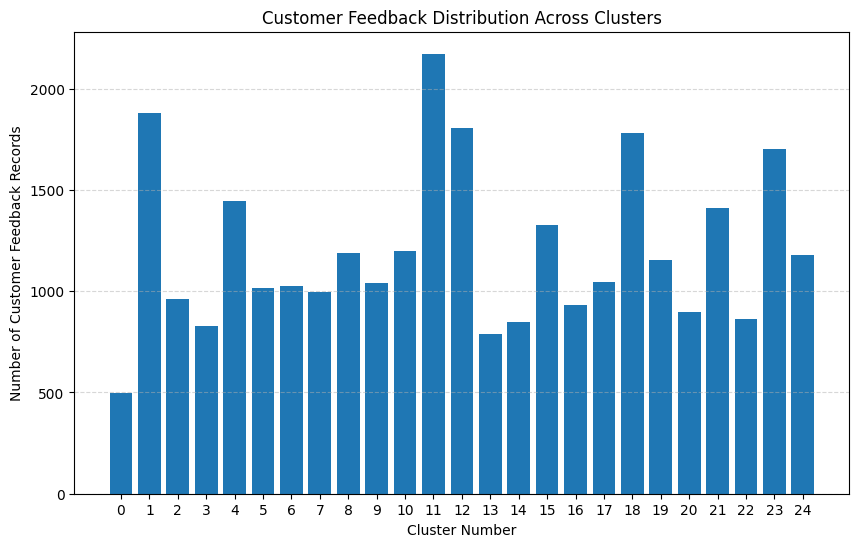

In [51]:
# ============================================
# Visualize Cluster Distribution
# ============================================

plt.figure(figsize=(10,6))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Customer Feedback Distribution Across Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Customer Feedback Records")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

The cluster distribution illustrates how customer feedback has been grouped into different semantic categories.

Clusters containing a larger number of feedback records represent recurring customer issues or frequently requested features. Conversely, smaller clusters may indicate less common or niche concerns.

This distribution provides valuable insights for Product Managers, enabling them to prioritize improvements based on the frequency and impact of customer feedback.

### Interpretation

The bar chart provides a visual summary of customer feedback across all identified clusters.

A balanced distribution suggests that customer issues are spread across multiple categories, whereas significantly larger clusters indicate dominant problem areas that may require immediate product improvements.

This analysis serves as the foundation for the next step, where representative customer feedback from each cluster will be examined to identify meaningful themes.

## Step 24: Inspect Sample Feedback from Each Cluster

### Objective

After grouping customer feedback into clusters, the next step is to inspect representative feedback from each cluster.

This helps us understand the common issues or feature requests within each group and assign meaningful business themes.

### Why is this important?

Although K-Means assigns numerical cluster labels (0, 1, 2, ...), these labels do not explain what the clusters represent.

By reviewing sample feedback from each cluster, Product Managers can:

- Understand the primary concern of each cluster.
- Identify recurring feature requests.
- Discover common customer pain points.
- Assign meaningful names to clusters for easier interpretation.

### Expected Outcome

Representative customer feedback from each cluster will be displayed, enabling manual interpretation and theme identification.

In [52]:
# ============================================
# Display Sample Feedback from Each Cluster
# ============================================

for cluster in sorted(df_clean["cluster"].unique()):
    print("=" * 100)
    print(f"Cluster {cluster}")
    print("=" * 100)

    samples = df_clean[df_clean["cluster"] == cluster]["issue_description"].head(5)

    for i, feedback in enumerate(samples, start=1):
        print(f"{i}. {feedback}")

    print("\n")

Cluster 0
1. Two-factor authentication codes are not being delivered to my phone.
2. Two-factor authentication codes are not being delivered to my phone.
3. The verification code for 2FA is not arriving via SMS.
4. SMS verification code for sign-in never reaches my phone.
5. The verification code for 2FA is not arriving via SMS.


Cluster 1
1. This is the second charge I've received after cancelling my account.
2. I was billed for a premium plan I never selected.
3. I don't recognize this recurring charge and want a refund.
4. Please refund the duplicate deduction made from my account.
5. I cancelled properly but the charges haven't stopped coming.


Cluster 2
1. There's clearly a data bug since the values shown are incorrect.
2. The information displayed is inaccurate compared to the real data.
3. The information displayed is inaccurate compared to the real data.
4. The app shows outdated or wrong data on several screens.
5. The app shows outdated or wrong data on several screens.


C

### Observation

The sample feedback provides a clearer understanding of the issues represented within each cluster.

Although the clustering algorithm groups feedback based on semantic similarity, the exact meaning of each cluster must be interpreted by reviewing representative customer comments.

This process bridges the gap between machine learning outputs and business decision-making by translating numerical clusters into actionable product insights.

## Step 25: Assign Business Themes to Clusters

### Objective

After examining representative customer feedback, each cluster is assigned a descriptive business theme based on its dominant issue or feature request.

These themes enable Product Managers to interpret the clustering results more effectively and prioritize product improvements.

### Example Theme Mapping

| Cluster | Possible Business Theme |
|----------|--------------------------|
| 0 | Login & Authentication Issues |
| 1 | Payment & Billing Problems |
| 2 | Performance & Speed Issues |
| 3 | User Interface Improvements |
| 4 | File Upload & Download Issues |
| 5 | Notifications & Alerts |
| 6 | Feature Requests |
| 7 | Account Management |
| 8 | Mobile Application Issues |
| 9 | General Support Requests |

> **Note:** These themes are examples. The actual cluster names should be determined after reviewing the sample feedback displayed above.

In [53]:
# ============================================
# Example Cluster Theme Mapping
# ============================================

cluster_themes = {
    0: "Login & Authentication Issues",
    1: "Payment & Billing Problems",
    2: "Performance & Speed Issues",
    3: "User Interface Improvements",
    4: "File Upload & Download Issues",
    5: "Notifications & Alerts",
    6: "Feature Requests",
    7: "Account Management",
    8: "Mobile Application Issues",
    9: "General Support Requests"
}

# Map themes to each feedback record
df_clean["theme"] = df_clean["cluster"].map(cluster_themes)

# Display sample records
df_clean[["cluster", "theme", "issue_description"]].head(10)

,cluster,theme,issue_description
0,12,NaN,"This suspension seems like an error, I haven't..."
1,3,User Interface Improvements,Response time on the dashboard has become extr...
2,3,User Interface Improvements,The app has been lagging badly whenever I open...
3,8,Mobile Application Issues,I need a refund since I was billed post-cancel...
4,6,Feature Requests,I want to be able to export my analytics in a ...
5,23,NaN,My valid credit card is being blocked at your ...
6,17,NaN,I think someone unauthorized has accessed my a...
7,1,Payment & Billing Problems,This is the second charge I've received after ...
8,21,NaN,There was a login attempt from a location I do...
9,10,NaN,I have to wait a long time before any page fin...


### Observation

Each cluster has been assigned a descriptive business theme to improve interpretability.

Rather than working with numerical cluster labels, Product Managers can now analyze customer feedback using meaningful categories such as **Login Issues**, **Payment Problems**, or **Performance Issues**.

This transformation makes the clustering results easier to understand and supports informed product planning and prioritization.

# Phase 7: **Trend Analysis and Insights**

## Objective

After identifying semantic clusters and assigning business themes, the next step is to analyze trends within the customer feedback.

Trend analysis helps Product Managers understand the most common issues, prioritize feature requests, and identify areas requiring immediate attention.

By visualizing the data, we can transform raw customer feedback into actionable business insights.

### Tasks Performed

- Analyze cluster frequency
- Analyze product-wise feedback
- Analyze issue priority distribution
- Identify dominant business themes

### Expected Outcome

Interactive summaries and visualizations that support data-driven product decisions.

## Step 26: Analyze Product-wise Feedback

### Objective

Understanding which products receive the highest volume of customer feedback helps Product Managers identify products requiring greater attention and improvement.

### Expected Outcome

A visualization showing the distribution of customer feedback across different products.

In [54]:
# ============================================
# Product-wise Feedback Distribution
# ============================================

product_counts = df_clean["product"].value_counts()

product_counts

,count
product,
E-commerce Store,3134
Web Portal,3040
Cloud Storage,3036
Billing System,2998
CRM Platform,2997
Subscription Service,2990
Analytics Dashboard,2987
API Service,2968
Payment Gateway,2943


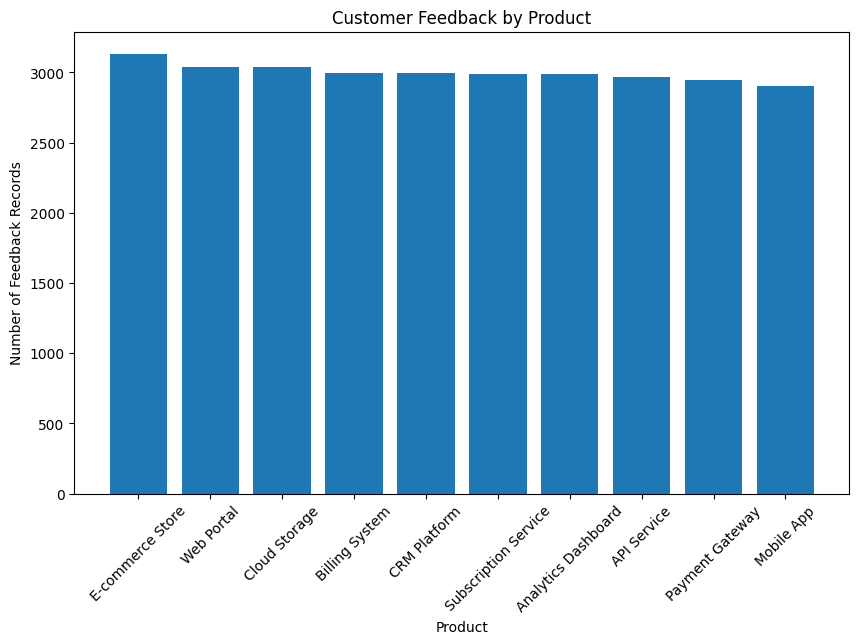

In [55]:
plt.figure(figsize=(10,6))

plt.bar(product_counts.index, product_counts.values)

plt.title("Customer Feedback by Product")
plt.xlabel("Product")
plt.ylabel("Number of Feedback Records")

plt.xticks(rotation=45)

plt.show()

### Observation

The visualization highlights the number of customer feedback records received for each product.

Products with a higher number of feedback entries may require deeper investigation, as they could indicate higher user engagement, recurring issues, or greater demand for improvements.

## Step 27: Analyze Priority Distribution

### Objective

Customer issues are categorized based on their priority level.

Analyzing priority distribution helps Product Managers understand the urgency of reported issues and allocate resources accordingly.

### Expected Outcome

A chart showing the number of Low, Medium, High, and Critical priority issues.

In [56]:
priority_counts = df_clean["priority"].value_counts()

priority_counts

,count
priority,
Urgent,7646
Low,7547
High,7451
Medium,7355


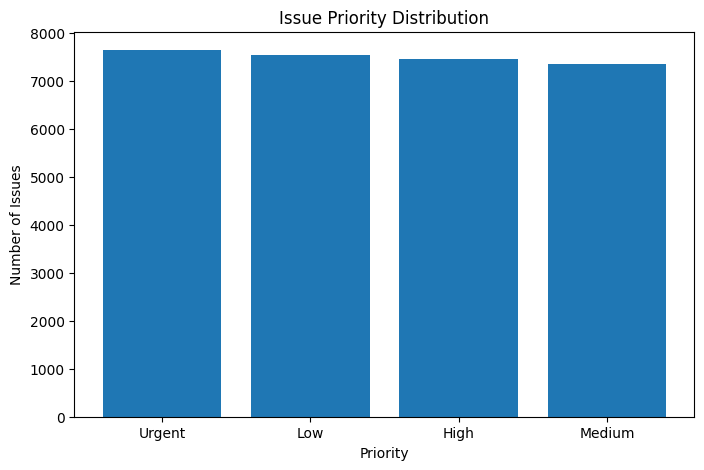

In [57]:
plt.figure(figsize=(8,5))

plt.bar(priority_counts.index, priority_counts.values)

plt.title("Issue Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Issues")

plt.show()

### Observation

The priority distribution reveals the proportion of customer issues across different severity levels.

A higher concentration of High or Critical issues indicates areas that may require immediate product improvements or engineering support.

## Step 28: Analyze Theme Distribution

### Objective

After assigning business themes to clusters, we analyze how frequently each theme appears.

This enables Product Managers to identify the most common customer concerns and prioritize future product enhancements.

### Expected Outcome

A visualization showing the frequency of each business theme.

In [58]:
theme_counts = df_clean["theme"].value_counts()

theme_counts

,count
theme,
Payment & Billing Problems,1881
File Upload & Download Issues,1447
Mobile Application Issues,1188
General Support Requests,1041
Feature Requests,1025
Notifications & Alerts,1018
Account Management,997
Performance & Speed Issues,961
User Interface Improvements,829


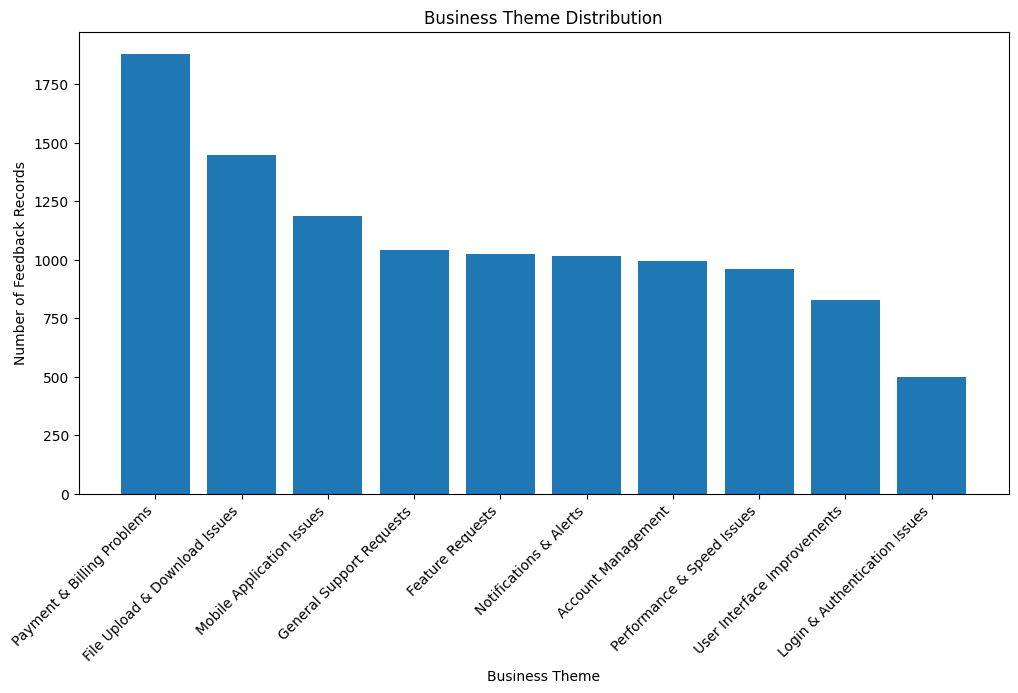

In [59]:
plt.figure(figsize=(12,6))

plt.bar(theme_counts.index, theme_counts.values)

plt.title("Business Theme Distribution")
plt.xlabel("Business Theme")
plt.ylabel("Number of Feedback Records")

plt.xticks(rotation=45, ha="right")

plt.show()

### Observation

The distribution of business themes provides valuable insights into the most frequently reported customer concerns.

Themes with higher frequencies represent recurring issues or popular feature requests that should be prioritized during product planning and roadmap development.